# IPL Team Performance & Match Analytics

**Type:** Data Analytics project (exploratory data analysis only — no machine learning)

**Goal:** Analyze historical IPL match data to uncover team-level performance patterns, toss-related trends, venue effects, and season-wise changes, using Python, Pandas, NumPy, Matplotlib and Seaborn.

**Dataset:** `data/matches.csv` — IPL match-level data, 2008 to 2024 (source: Kaggle, "IPL Complete Dataset (2008-2024)" by patrickb1912, originally sourced from Cricsheet).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

VIS_DIR = '../visualizations'


## 1. Data Loading

In [2]:
df = pd.read_csv('../data/matches.csv')

print("Shape (rows, columns):", df.shape)
print("\nColumns:", list(df.columns))


Shape (rows, columns): (1095, 20)

Columns: ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


In [3]:
df.dtypes

id                   int64
season                 str
city                   str
date                   str
match_type             str
player_of_match        str
venue                  str
team1                  str
team2                  str
toss_winner            str
toss_decision          str
winner                 str
result                 str
result_margin      float64
target_runs        float64
target_overs       float64
super_over             str
method                 str
umpire1                str
umpire2                str
dtype: object

In [4]:
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


### Checking for missing values and duplicates

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

print("\nNumber of duplicate rows:", df.duplicated().sum())


Columns with missing values:
method             1074
city                 51
result_margin        19
winner                5
player_of_match       5
target_runs           3
target_overs          3
dtype: int64

Number of duplicate rows: 0


**Observations:**
- The dataset has 1,095 matches and 20 columns, with no duplicate rows.
- `method` is missing for 1,074 rows — this is expected, since it only records the reduction method (e.g. D/L) for rain-affected matches; most matches don't need it.
- `city` is missing for 51 rows — these correspond to matches played at neutral/international venues where the source data didn't tag a city (e.g. UAE-hosted seasons).
- `winner`, `player_of_match` are missing for 5 rows each — these are all `result == 'no result'` matches (washed out / abandoned), so there is genuinely no winner or player of the match to record.
- `result_margin`, `target_runs`, `target_overs` have a handful of missing values, also tied to no-result or tied matches where a margin doesn't apply.


## 2. Data Cleaning

**Cleaning steps performed:**

1. **Standardize team names** — some franchises were renamed over the years (same team, new brand name). We map old names to their current name so that a team's full history is tracked under one name:
   - `Delhi Daredevils` → `Delhi Capitals`
   - `Kings XI Punjab` → `Punjab Kings`
   - `Royal Challengers Bangalore` → `Royal Challengers Bengaluru`
   - `Rising Pune Supergiant` → `Rising Pune Supergiants` (inconsistent spelling across seasons)

   Note: `Deccan Chargers` is **not** merged into `Sunrisers Hyderabad`. Although both are Hyderabad franchises, Deccan Chargers was terminated by the BCCI in 2012 and Sunrisers Hyderabad is a separate franchise that started in 2013 — merging them would misrepresent the data.

2. **Convert `date` to a proper datetime type**, and keep the original `season` label as the grouping key for season-wise analysis (some seasons, like `2009` and `2009/10`, are separate real seasons even though they'd collide if we naively took just the starting year — so we group by the full season string).

3. **Handle missing values**:
   - `city`: filled with `'Unknown'` (venue is still available for location-based analysis).
   - `winner`, `player_of_match`, `result_margin`: left as `NaN` — these are genuinely inapplicable for no-result/tied matches, and we exclude those rows from win/margin calculations rather than guessing a value.
   - `method`: filled with `'Normal'` to mean "no D/L adjustment applied".

4. **Duplicate check**: none found, but we run `.drop_duplicates()` defensively in case new data is appended later.


In [6]:
df_clean = df.copy()

# 1. Standardize team names (same franchise, renamed)
name_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
}
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    df_clean[col] = df_clean[col].replace(name_mapping)

# 2. Convert date to datetime; keep 'season' string as the season key
df_clean['date'] = pd.to_datetime(df_clean['date'])

# Chronological order of seasons, used later for ordering plots
season_order = df_clean.groupby('season')['date'].min().sort_values().index.tolist()

# 3. Handle missing values
df_clean['city'] = df_clean['city'].fillna('Unknown')
df_clean['method'] = df_clean['method'].fillna('Normal')
# winner / player_of_match / result_margin / target_runs / target_overs are left as NaN
# on purpose -- they are genuinely inapplicable for no-result / tied matches.

# 4. Duplicate check (defensive)
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
after = df_clean.shape[0]
print(f"Rows before dedup: {before}, after dedup: {after}")

print("\nRemaining missing values:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])


Rows before dedup: 1095, after dedup: 1095

Remaining missing values:
player_of_match     5
winner              5
result_margin      19
target_runs         3
target_overs        3
dtype: int64


In [7]:
# Matches with no result (excluded from win/loss and margin calculations later)
no_result_df = df_clean[df_clean['result'] == 'no result']
decisive_df = df_clean[df_clean['result'] != 'no result'].copy()

print(f"Total matches: {len(df_clean)}")
print(f"No-result matches: {len(no_result_df)}")
print(f"Decisive matches (used for win-rate / margin analysis): {len(decisive_df)}")


Total matches: 1095
No-result matches: 5
Decisive matches (used for win-rate / margin analysis): 1090


## 3. Exploratory Data Analysis

### A. Overall Team Performance

For each team we compute: matches played, wins, losses and win percentage. Win percentage is calculated over **decisive matches only** (excluding no-result games), since a team can't be credited a win or loss for a washed-out match.


In [8]:
teams = pd.unique(df_clean[['team1', 'team2']].values.ravel())

records = []
for t in teams:
    played = df_clean[(df_clean['team1'] == t) | (df_clean['team2'] == t)]
    no_result = played[played['result'] == 'no result'].shape[0]
    decisive = played.shape[0] - no_result
    wins = played[played['winner'] == t].shape[0]
    losses = decisive - wins
    win_pct = (wins / decisive * 100) if decisive > 0 else 0
    records.append([t, played.shape[0], wins, losses, no_result, round(win_pct, 2)])

team_stats = pd.DataFrame(
    records,
    columns=['team', 'matches_played', 'wins', 'losses', 'no_result', 'win_pct']
).sort_values('wins', ascending=False).reset_index(drop=True)

team_stats


,team,matches_played,wins,losses,no_result,win_pct
0,Mumbai Indians,261,144,117,0,55.17
1,Chennai Super Kings,238,138,99,1,58.23
2,Kolkata Knight Riders,251,131,120,0,52.19
3,Royal Challengers Bengaluru,255,123,129,3,48.81
4,Delhi Capitals,252,115,135,2,46.00
5,Punjab Kings,246,112,134,0,45.53
6,Rajasthan Royals,221,112,107,2,51.14
7,Sunrisers Hyderabad,182,88,94,0,48.35
8,Deccan Chargers,75,29,46,0,38.67
9,Gujarat Titans,45,28,17,0,62.22


**Win percentage, teams with at least 30 matches played** (filters out small-sample franchises like the 2022 expansion teams from dominating the ranking on too few games):

In [9]:
established_teams = team_stats[team_stats['matches_played'] >= 30].sort_values('win_pct', ascending=False)
established_teams


,team,matches_played,wins,losses,no_result,win_pct
9,Gujarat Titans,45,28,17,0,62.22
1,Chennai Super Kings,238,138,99,1,58.23
10,Lucknow Super Giants,44,24,19,1,55.81
0,Mumbai Indians,261,144,117,0,55.17
2,Kolkata Knight Riders,251,131,120,0,52.19
6,Rajasthan Royals,221,112,107,2,51.14
11,Rising Pune Supergiants,30,15,15,0,50.00
3,Royal Challengers Bengaluru,255,123,129,3,48.81
7,Sunrisers Hyderabad,182,88,94,0,48.35
4,Delhi Capitals,252,115,135,2,46.00


### B. Season-wise Performance


In [10]:
matches_per_season = df_clean.groupby('season').size().reindex(season_order)
matches_per_season


season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
dtype: int64

In [11]:
# Wins per team per season (pivot), ordered chronologically
season_team_wins = (
    df_clean[df_clean['winner'].notnull()]
    .groupby(['season', 'winner'])
    .size()
    .unstack(fill_value=0)
    .reindex(season_order)
)

# Focus on the 4 teams with the most all-time wins, to see how they trended over time
top4_teams = team_stats.sort_values('wins', ascending=False).head(4)['team'].tolist()
season_team_wins[top4_teams]


winner,Mumbai Indians,Chennai Super Kings,Kolkata Knight Riders,Royal Challengers Bengaluru
season,,,,
2007/08,7,9,6,4
2009,5,8,3,9
2009/10,11,9,7,8
2011,10,11,8,10
2012,10,10,12,8
2013,13,12,6,9
2014,7,10,11,5
2015,10,10,7,8
2016,7,0,8,9


**Observation:** looking at the top 4 all-time win-count teams season by season shows real fluctuation rather than one team always dominating — e.g. Chennai Super Kings did not play the 2016 and 2017 seasons (franchise suspension), which shows up as zero wins those years, while Mumbai Indians and Kolkata Knight Riders remained active every season.

### C. Toss Analysis


In [12]:
toss_decision_counts = df_clean['toss_decision'].value_counts()
toss_decision_counts


toss_decision
field    704
bat      391
Name: count, dtype: int64

In [13]:
toss_winner_is_match_winner = (decisive_df['toss_winner'] == decisive_df['winner']).sum()
toss_win_pct = toss_winner_is_match_winner / len(decisive_df) * 100

print(f"Toss winner also won the match: {toss_winner_is_match_winner} / {len(decisive_df)} = {toss_win_pct:.2f}%")


Toss winner also won the match: 554 / 1090 = 50.83%


In [14]:
bat_first = decisive_df[decisive_df['toss_decision'] == 'bat']
field_first = decisive_df[decisive_df['toss_decision'] == 'field']

bat_first_toss_win = (bat_first['toss_winner'] == bat_first['winner']).sum()
field_first_toss_win = (field_first['toss_winner'] == field_first['winner']).sum()

bat_first_pct = bat_first_toss_win / len(bat_first) * 100
field_first_pct = field_first_toss_win / len(field_first) * 100

print(f"Chose to BAT first after winning toss -> went on to win: {bat_first_toss_win}/{len(bat_first)} = {bat_first_pct:.2f}%")
print(f"Chose to FIELD first after winning toss -> went on to win: {field_first_toss_win}/{len(field_first)} = {field_first_pct:.2f}%")


Chose to BAT first after winning toss -> went on to win: 177/390 = 45.38%
Chose to FIELD first after winning toss -> went on to win: 377/700 = 53.86%


**Observation:** teams choose to field first far more often (704 vs 391 matches), and fielding first after winning the toss converts to a match win noticeably more often than batting first (~54% vs ~45%). This lines up with the common T20 strategy of chasing under lights / with a clearer target in view.

### D. Venue Analysis


In [15]:
venue_counts = df_clean['venue'].value_counts()
top_venues = venue_counts.head(10)
top_venues


venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64

In [16]:
# Team performance at the single most-used venue
top_venue_name = top_venues.index[0]
at_top_venue = df_clean[df_clean['venue'] == top_venue_name]
wins_at_top_venue = at_top_venue['winner'].value_counts().head(5)

print(f"Most-used venue: {top_venue_name} ({top_venues.iloc[0]} matches)")
print("\nTop 5 teams by wins at this venue:")
wins_at_top_venue


Most-used venue: Eden Gardens (77 matches)

Top 5 teams by wins at this venue:


winner
Kolkata Knight Riders          45
Mumbai Indians                 10
Chennai Super Kings             5
Royal Challengers Bengaluru     4
Punjab Kings                    3
Name: count, dtype: int64

### E. Win Margin Analysis


In [17]:
result_counts = decisive_df['result'].value_counts()
result_counts


result
wickets    578
runs       498
tie         14
Name: count, dtype: int64

In [18]:
runs_margin = decisive_df.loc[decisive_df['result'] == 'runs', 'result_margin']
wkts_margin = decisive_df.loc[decisive_df['result'] == 'wickets', 'result_margin']

print(f"Wins by runs: {len(runs_margin)} matches, average margin = {runs_margin.mean():.1f} runs, largest margin = {runs_margin.max():.0f} runs")
print(f"Wins by wickets: {len(wkts_margin)} matches, average margin = {wkts_margin.mean():.1f} wickets, largest margin = {wkts_margin.max():.0f} wickets")


Wins by runs: 498 matches, average margin = 30.1 runs, largest margin = 146 runs
Wins by wickets: 578 matches, average margin = 6.2 wickets, largest margin = 10 wickets


**Observation:** wickets-based wins (578) are more common than runs-based wins (498), consistent with the toss finding above — teams that field first and chase are winning more often, and a chase that succeeds is recorded as a wickets-margin win.

## 4. Visualizations

All 8 plots below are also saved as PNG files inside the `visualizations/` folder.


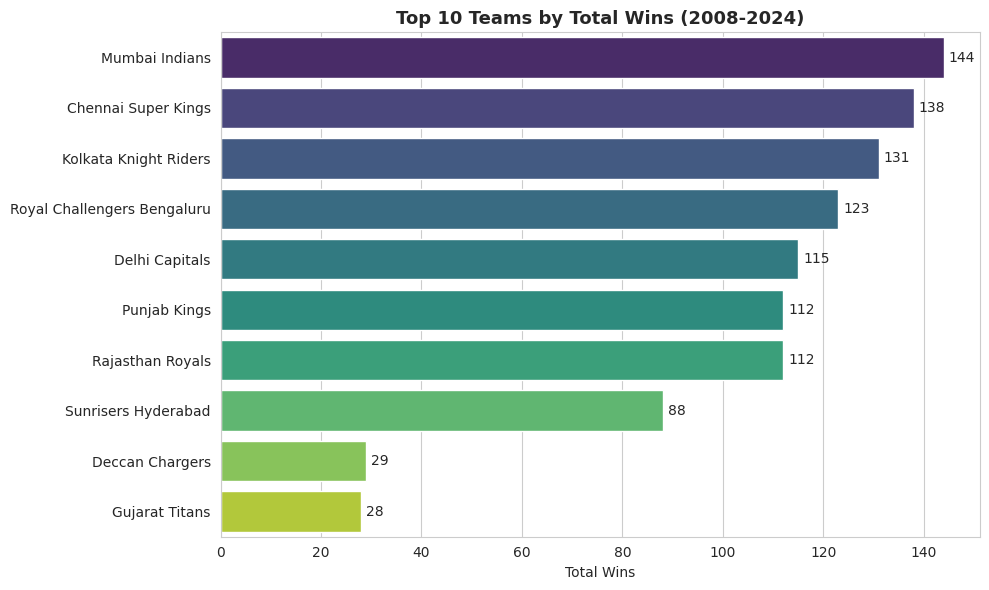

In [19]:
# 1. Top teams by total wins
plt.figure(figsize=(10, 6))
top10_wins = team_stats.sort_values('wins', ascending=False).head(10)
sns.barplot(data=top10_wins, x='wins', y='team', hue='team', palette='viridis', legend=False)
plt.title('Top 10 Teams by Total Wins (2008-2024)', fontsize=13, fontweight='bold')
plt.xlabel('Total Wins')
plt.ylabel('')
for i, v in enumerate(top10_wins['wins']):
    plt.text(v + 1, i, str(v), va='center')
plt.tight_layout()
plt.savefig(f'{VIS_DIR}/01_top_teams_by_wins.png', dpi=150, bbox_inches='tight')
plt.show()


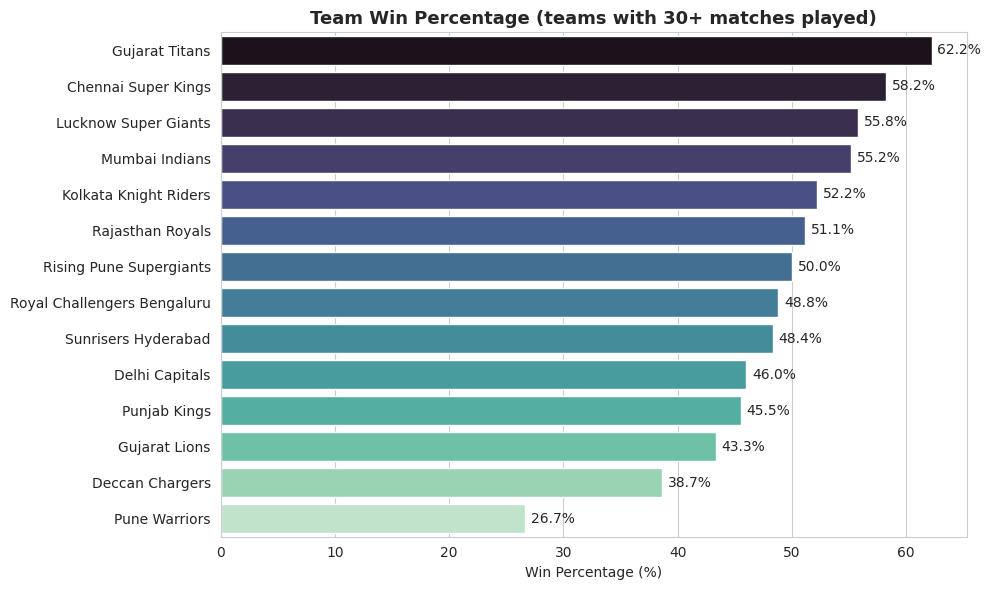

In [20]:
# 2. Team win percentage (min 30 matches played)
plt.figure(figsize=(10, 6))
win_pct_sorted = established_teams.sort_values('win_pct', ascending=False)
sns.barplot(data=win_pct_sorted, x='win_pct', y='team', hue='team', palette='mako', legend=False)
plt.title('Team Win Percentage (teams with 30+ matches played)', fontsize=13, fontweight='bold')
plt.xlabel('Win Percentage (%)')
plt.ylabel('')
for i, v in enumerate(win_pct_sorted['win_pct']):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.savefig(f'{VIS_DIR}/02_team_win_percentage.png', dpi=150, bbox_inches='tight')
plt.show()


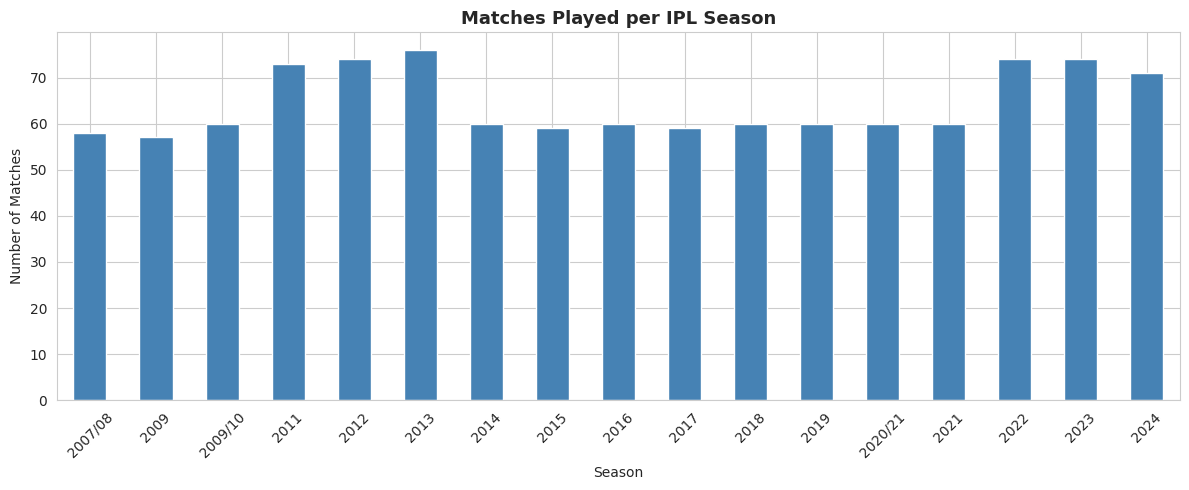

In [21]:
# 3. Matches played by season
plt.figure(figsize=(12, 5))
matches_per_season.plot(kind='bar', color='steelblue')
plt.title('Matches Played per IPL Season', fontsize=13, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{VIS_DIR}/03_matches_by_season.png', dpi=150, bbox_inches='tight')
plt.show()


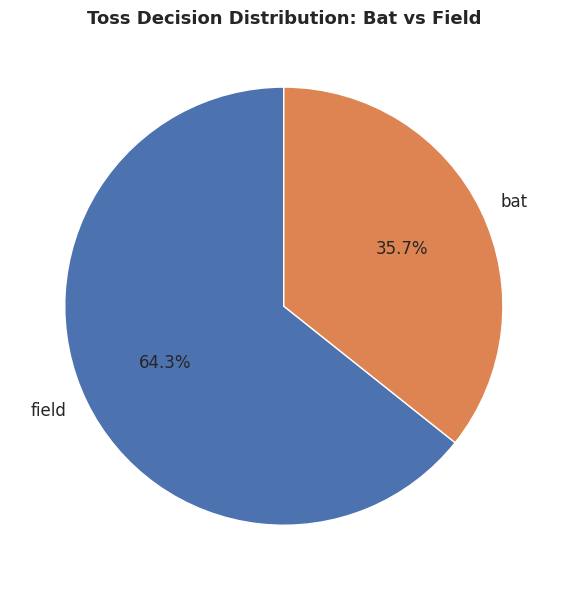

In [22]:
# 4. Toss decision distribution
plt.figure(figsize=(6, 6))
colors = ['#4C72B0', '#DD8452']
plt.pie(toss_decision_counts.values, labels=toss_decision_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize': 12})
plt.title('Toss Decision Distribution: Bat vs Field', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIS_DIR}/04_toss_decision_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


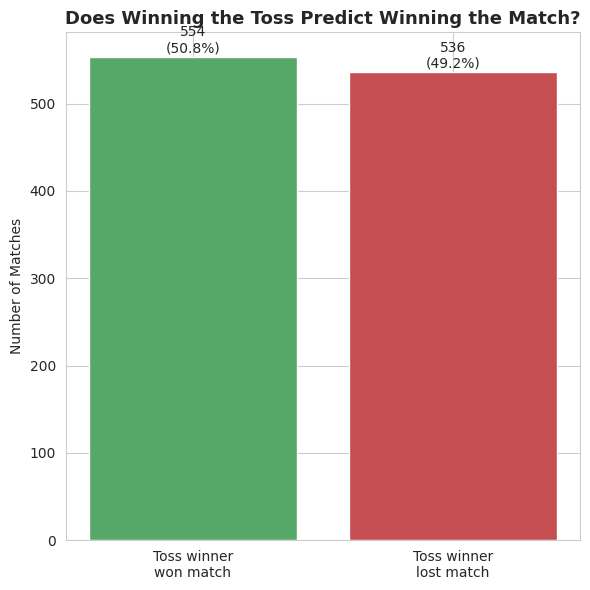

In [23]:
# 5. Toss winner vs match winner
labels = ['Toss winner\nwon match', 'Toss winner\nlost match']
values = [toss_winner_is_match_winner, len(decisive_df) - toss_winner_is_match_winner]

plt.figure(figsize=(6, 6))
plt.bar(labels, values, color=['#55A868', '#C44E52'])
plt.title('Does Winning the Toss Predict Winning the Match?', fontsize=13, fontweight='bold')
plt.ylabel('Number of Matches')
for i, v in enumerate(values):
    plt.text(i, v + 5, f'{v}\n({v/len(decisive_df)*100:.1f}%)', ha='center')
plt.tight_layout()
plt.savefig(f'{VIS_DIR}/05_toss_winner_vs_match_winner.png', dpi=150, bbox_inches='tight')
plt.show()


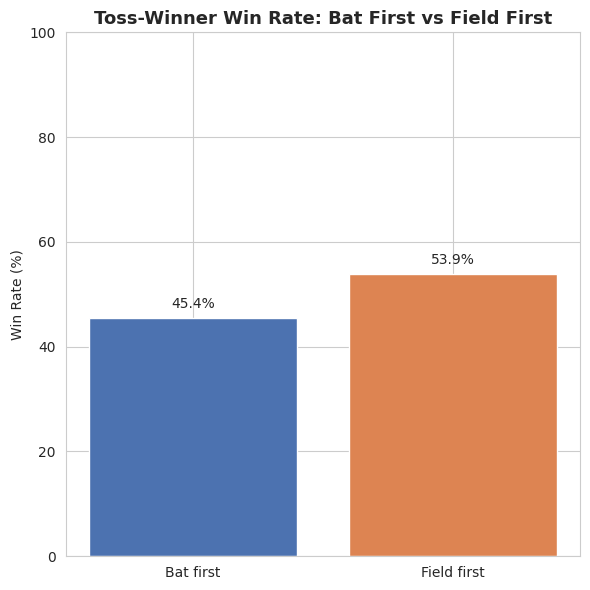

In [24]:
# 6. Batting-first vs fielding-first outcomes (for the toss-winning team)
plt.figure(figsize=(6, 6))
labels = ['Bat first', 'Field first']
values = [bat_first_pct, field_first_pct]
plt.bar(labels, values, color=['#4C72B0', '#DD8452'])
plt.title('Toss-Winner Win Rate: Bat First vs Field First', fontsize=13, fontweight='bold')
plt.ylabel('Win Rate (%)')
plt.ylim(0, 100)
for i, v in enumerate(values):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.savefig(f'{VIS_DIR}/06_bat_vs_field_first_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()


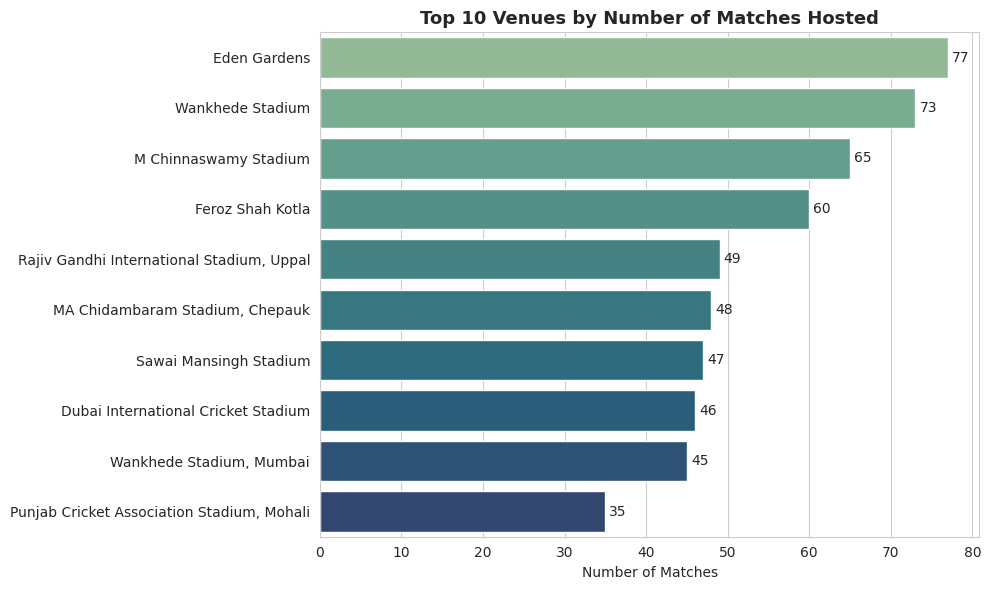

In [25]:
# 7. Top venues by number of matches
plt.figure(figsize=(10, 6))
sns.barplot(x=top_venues.values, y=top_venues.index, hue=top_venues.index, palette='crest', legend=False)
plt.title('Top 10 Venues by Number of Matches Hosted', fontsize=13, fontweight='bold')
plt.xlabel('Number of Matches')
plt.ylabel('')
for i, v in enumerate(top_venues.values):
    plt.text(v + 0.5, i, str(v), va='center')
plt.tight_layout()
plt.savefig(f'{VIS_DIR}/07_top_venues.png', dpi=150, bbox_inches='tight')
plt.show()


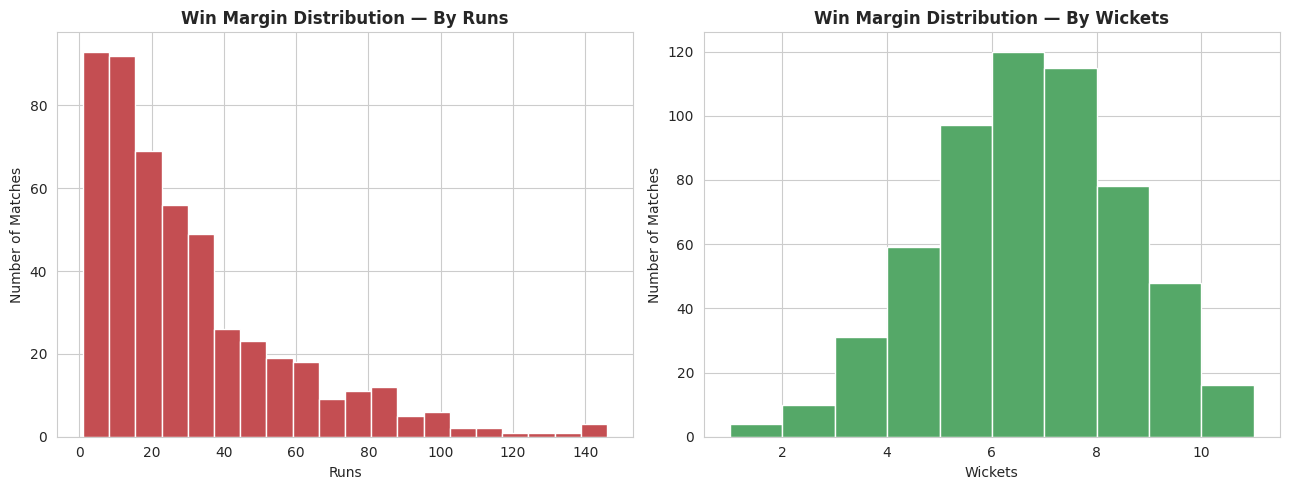

In [26]:
# 8. Win margin distribution (runs-based vs wickets-based)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(runs_margin, bins=20, color='#C44E52', edgecolor='white')
axes[0].set_title('Win Margin Distribution — By Runs', fontweight='bold')
axes[0].set_xlabel('Runs')
axes[0].set_ylabel('Number of Matches')

axes[1].hist(wkts_margin, bins=range(1, 12), color='#55A868', edgecolor='white')
axes[1].set_title('Win Margin Distribution — By Wickets', fontweight='bold')
axes[1].set_xlabel('Wickets')
axes[1].set_ylabel('Number of Matches')

plt.tight_layout()
plt.savefig(f'{VIS_DIR}/08_win_margin_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Key Findings

*(These are generated from the printed results above — every number here is filled in programmatically from the actual dataset, not hard-coded.)*


In [27]:
top_team = team_stats.sort_values('wins', ascending=False).iloc[0]
best_win_pct_team = established_teams.iloc[0]
most_used_venue = top_venues.index[0]

findings = f"""
KEY FINDINGS
============

1. {top_team['team']} has the most all-time wins in IPL history: {int(top_team['wins'])} wins from {int(top_team['matches_played'])} matches played.

2. Among teams with 30+ matches played, {best_win_pct_team['team']} has the highest win percentage at {best_win_pct_team['win_pct']:.2f}%, ahead of {established_teams.iloc[1]['team']} ({established_teams.iloc[1]['win_pct']:.2f}%) and {established_teams.iloc[2]['team']} ({established_teams.iloc[2]['win_pct']:.2f}%).

3. Fielding first is by far the more common toss decision: {toss_decision_counts['field']} matches ({toss_decision_counts['field']/toss_decision_counts.sum()*100:.1f}%) vs {toss_decision_counts['bat']} matches ({toss_decision_counts['bat']/toss_decision_counts.sum()*100:.1f}%) choosing to bat first.

4. Winning the toss is only a slight edge: the toss winner goes on to win the match {toss_win_pct:.2f}% of the time ({toss_winner_is_match_winner}/{len(decisive_df)} matches) -- close to a coin flip, not a strong predictor.

5. Choosing to field first after winning the toss converts to a match win more often ({field_first_pct:.2f}%) than choosing to bat first ({bat_first_pct:.2f}%), a gap of about {field_first_pct - bat_first_pct:.1f} percentage points.

6. {most_used_venue} is the most-used venue in IPL history, hosting {top_venues.iloc[0]} matches -- {top_venues.iloc[0] - top_venues.iloc[1]} more than the second most-used venue, {top_venues.index[1]}.

7. Wickets-based wins ({len(wkts_margin)} matches) are more common than runs-based wins ({len(runs_margin)} matches), consistent with the fielding-first advantage above -- more matches are decided by a successful run chase than by defending a total.

8. The average margin differs sharply by win type: matches won by defending a total are won by an average of {runs_margin.mean():.1f} runs, while matches won by chasing are won by an average of {wkts_margin.mean():.1f} wickets -- meaning most successful chases finish comfortably rather than in a nail-biter.
"""

print(findings)

with open(f'{VIS_DIR}/../key_findings.txt', 'w') as f:
    f.write(findings)



KEY FINDINGS

1. Mumbai Indians has the most all-time wins in IPL history: 144 wins from 261 matches played.

2. Among teams with 30+ matches played, Gujarat Titans has the highest win percentage at 62.22%, ahead of Chennai Super Kings (58.23%) and Lucknow Super Giants (55.81%).

3. Fielding first is by far the more common toss decision: 704 matches (64.3%) vs 391 matches (35.7%) choosing to bat first.

4. Winning the toss is only a slight edge: the toss winner goes on to win the match 50.83% of the time (554/1090 matches) -- close to a coin flip, not a strong predictor.

5. Choosing to field first after winning the toss converts to a match win more often (53.86%) than choosing to bat first (45.38%), a gap of about 8.5 percentage points.

6. Eden Gardens is the most-used venue in IPL history, hosting 77 matches -- 4 more than the second most-used venue, Wankhede Stadium.

7. Wickets-based wins (578 matches) are more common than runs-based wins (498 matches), consistent with the fieldi

## Summary

This notebook loaded, cleaned and analyzed 1,095 IPL matches (2008-2024) across team performance, season trends, toss impact, venue effects and win margins, using only Pandas/NumPy for computation and Matplotlib/Seaborn for visualization — no machine learning involved. All findings above are derived directly from the dataset's actual values.